---
title: "Forecast Daily Spare-parts Demand with TabPFN"
description: "Compare local and pooled TabPFN regressors on synthetic demand from German manufacturing plants"
icon: "chart-line"
cookbookTags:
  - time-series
  - regression
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

Spare-parts demand is a panel forecasting problem: related daily series share calendar and operational patterns, but each part and plant also behaves differently. This recipe compares four `TabPFNRegressor` strategies: one model per **series**, one per **product category**, one per **location**, and a single **global** model.

> The data is synthetic and does not represent any real company's operations.

## Setup and data

In [1]:
import importlib.util

required = ("tabpfn", "pandas", "sklearn", "matplotlib")
if not all(importlib.util.find_spec(package) for package in required):
    %pip install -q tabpfn pandas scikit-learn matplotlib

In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning)

import urllib.request
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from tabpfn import TabPFNRegressor

plt.style.use("seaborn-v0_8-whitegrid")
# Synthetic demand panel shipped with the cookbook (scripts/generate_spare_parts_data.py).
DATA_PATH = Path("../datasets/forecast_spare_parts_demand/spare_parts_daily.csv")
if not DATA_PATH.exists():  # not running from a repo checkout, e.g. on Colab
    DATA_PATH = Path("spare_parts_daily.csv")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/PriorLabs/tabpfn-cookbook/main/datasets/forecast_spare_parts_demand/spare_parts_daily.csv",
        DATA_PATH,
    )
panel = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"{len(panel):,} rows | {panel['series_id'].nunique()} daily series | "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")

8,772 rows | 12 daily series | 2023-01-01 to 2024-12-31


### A few demand series

The selected series deliberately show different demand regimes: steady consumption, periodic replenishment, strong annual seasonality, and intermittent bulk orders.

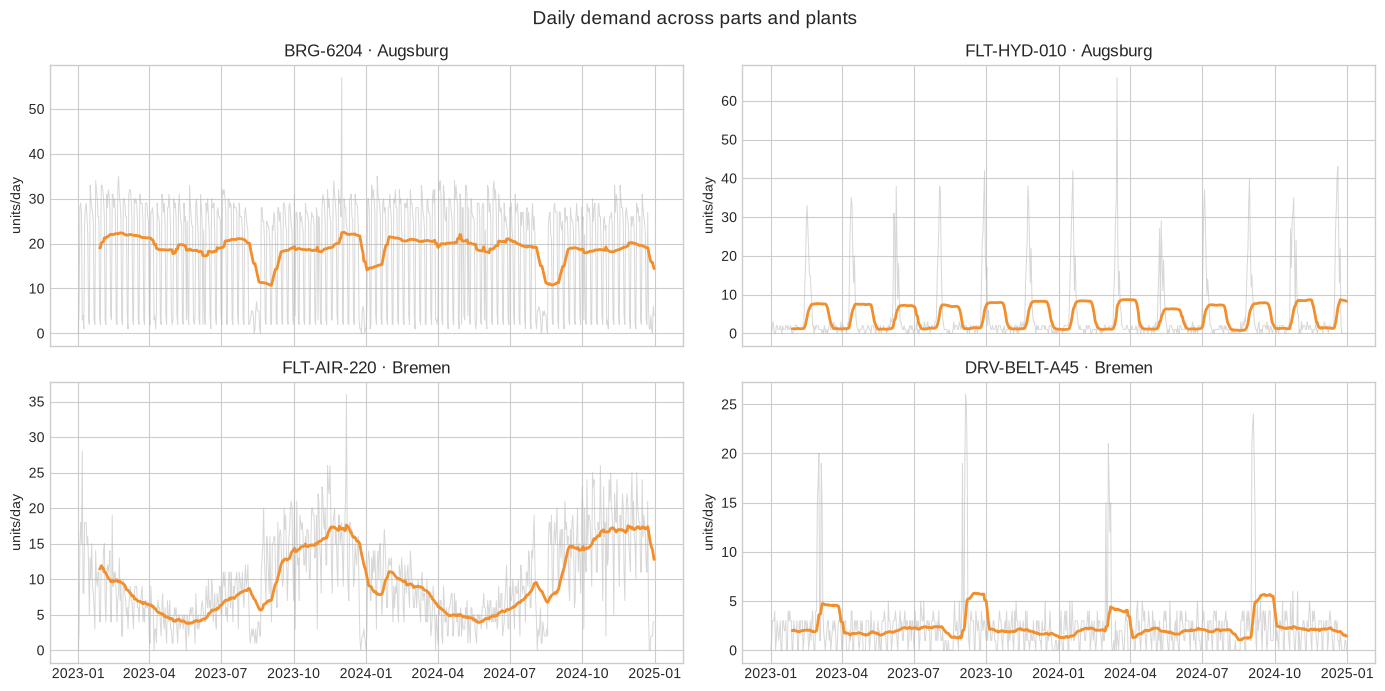

In [3]:
EXAMPLES = [
    "BRG-6204 · Augsburg", "FLT-HYD-010 · Augsburg",
    "FLT-AIR-220 · Bremen", "DRV-BELT-A45 · Bremen",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, series_id in zip(axes.flat, EXAMPLES):
    series = panel.loc[panel["series_id"].eq(series_id)].set_index("date")["demand"]
    ax.plot(series, color="#B7B7B7", alpha=0.55, linewidth=0.7)
    ax.plot(series.rolling(28).mean(), color="#F28E2B", linewidth=2)
    ax.set(title=series_id, ylabel="units/day")
fig.suptitle("Daily demand across parts and plants", fontsize=14)
fig.tight_layout()
plt.show()

## Build leakage-safe time-series features

Each target day becomes a tabular row with calendar variables, weekly and annual Fourier terms, lags, and shifted rolling statistics. Every demand-derived feature starts at `shift(1)`, so it uses only information available before the target day.

In [4]:
def add_features(data):
    data = data.sort_values(["series_id", "date"]).copy()
    day = (data["date"] - data["date"].min()).dt.days
    data["day_of_week"] = data["date"].dt.dayofweek
    data["month"] = data["date"].dt.month
    data["time_index"] = day
    for period, harmonics, name in [(7, 1, "week"), (365.25, 2, "year")]:
        for harmonic in range(1, harmonics + 1):
            angle = 2 * np.pi * harmonic * day / period
            data[f"{name}_sin_{harmonic}"] = np.sin(angle)
            data[f"{name}_cos_{harmonic}"] = np.cos(angle)

    demand = data.groupby("series_id", observed=True)["demand"]
    for lag in (1, 2, 7, 14, 28, 56):
        data[f"lag_{lag}"] = demand.shift(lag)
    shifted = demand.shift(1)
    for window in (7, 28):
        rolling = shifted.groupby(data["series_id"], observed=True).rolling(window)
        for statistic in ("mean", "std", "median", "max"):
            data[f"rolling_{statistic}_{window}"] = getattr(rolling, statistic)().droplevel(0)
    return data.dropna().reset_index(drop=True)


featured = add_features(panel)
featured.filter(regex="^(date|series_id|demand|lag_|rolling_|week_|year_)").head()

,date,demand,series_id,week_sin_1,week_cos_1,year_sin_1,year_cos_1,year_sin_2,year_cos_2,lag_1,...,lag_28,lag_56,rolling_mean_7,rolling_std_7,rolling_median_7,rolling_max_7,rolling_mean_28,rolling_std_28,rolling_median_28,rolling_max_28
0,2023-02-26,2,BRG-6204 · Augsburg,-1.959435e-15,1.000000,0.821100,0.570784,0.937342,-0.348411,3.0,...,2.0,0.0,22.571429,13.986388,29.0,35.0,22.357143,12.798189,28.5,35.0
1,2023-02-27,30,BRG-6204 · Augsburg,7.818315e-01,0.623490,0.830797,0.556576,0.924803,-0.380447,2.0,...,33.0,6.0,22.571429,13.986388,29.0,35.0,22.357143,12.798189,28.5,35.0
2,2023-02-28,30,BRG-6204 · Augsburg,9.749279e-01,-0.222521,0.840248,0.542202,0.911169,-0.412034,30.0,...,33.0,28.0,22.285714,13.780594,29.0,35.0,22.250000,12.718097,28.5,35.0
3,2023-03-01,29,BRG-6204 · Augsburg,4.338837e-01,-0.900969,0.849450,0.527668,0.896456,-0.443132,30.0,...,32.0,29.0,21.571429,13.125765,29.0,31.0,22.142857,12.636556,28.5,35.0
4,2023-03-02,26,BRG-6204 · Augsburg,-4.338837e-01,-0.900969,0.858402,0.512978,0.880683,-0.473706,29.0,...,30.0,27.0,21.285714,12.906255,29.0,30.0,22.035714,12.562384,28.5,35.0


## Hold out four weeks

This is a rolling next-day evaluation: for each test date, the previous day's observed demand is available. Static labels are one-hot encoded so pooled models can distinguish their member series.

In [5]:
cutoff = featured["date"].max() - pd.Timedelta(days=27)
static = ["part_id", "category", "location"]
encoded = pd.get_dummies(featured, columns=static, dtype=float)
encoded[static] = featured[static]
excluded = {"date", "part_name", "state_code", "series_id", "demand", *static}
features = [column for column in encoded if column not in excluded]
train, test = encoded[encoded["date"] < cutoff], encoded[encoded["date"] >= cutoff]
print(f"{len(train):,} training rows, {len(test):,} test rows, {len(features)} features")

7,764 training rows, 336 test rows, 37 features


## Fit local, grouped, and global models

The helper changes only which rows are pooled. It otherwise uses `TabPFNRegressor` defaults, requests the predictive mean, and takes the 10th and 90th percentiles as an 80% predictive interval. Constant columns are removed within each pool.

In [6]:
def fit_by(group_column, strategy):
    groups = [(None, test)] if group_column is None else test.groupby(group_column, observed=True)
    results = []
    for value, test_group in groups:
        train_group = train if group_column is None else train[train[group_column] == value]
        usable = [column for column in features if train_group[column].nunique() > 1]
        fill = train_group[usable].median()
        model = TabPFNRegressor()
        model.fit(train_group[usable].fillna(fill), train_group["demand"])
        distribution = model.predict(
            test_group[usable].fillna(fill), output_type="main", quantiles=[0.1, 0.9]
        )
        lower, upper = distribution["quantiles"]
        results.append(test_group[["date", "series_id", "demand"]].assign(
            strategy=strategy, prediction=np.clip(distribution["mean"], 0, None),
            lower=np.clip(lower, 0, None), upper=np.clip(upper, 0, None),
        ))
    return pd.concat(results, ignore_index=True)


predictions = pd.concat([
    fit_by("series_id", "Series by series"),
    fit_by("category", "Product category"),
    fit_by("location", "Location"),
    fit_by(None, "Global"),
])

## Compare pooling strategies

In [7]:
def score(group):
    actual, predicted = group["demand"], group["prediction"]
    return pd.Series({
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": root_mean_squared_error(actual, predicted),
        "WAPE (%)": 100 * np.abs(actual - predicted).sum() / actual.sum(),
        "80% coverage (%)": 100 * ((actual >= group["lower"]) & (actual <= group["upper"])).mean(),
    })


metrics = predictions.groupby("strategy").apply(score, include_groups=False).sort_values("WAPE (%)").round(2)
metrics

,MAE,RMSE,WAPE (%),80% coverage (%)
strategy,,,,
Global,1.04,1.59,13.81,90.48
Series by series,1.11,1.68,14.79,88.99
Product category,1.12,1.61,14.86,91.07
Location,1.12,1.71,14.93,90.18


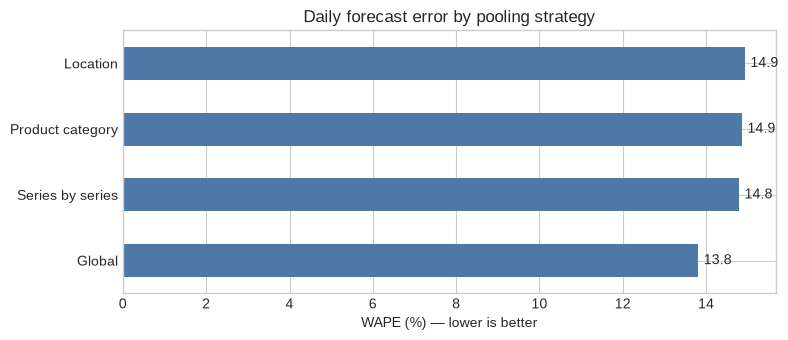

In [8]:
ax = metrics["WAPE (%)"].sort_values().plot.barh(figsize=(8, 3.5), color="#4E79A7")
ax.set(title="Daily forecast error by pooling strategy", xlabel="WAPE (%) — lower is better", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f", padding=4)
plt.tight_layout()
plt.show()

### Forecasts with predictive intervals

Separate panels compare the four strategies on a steady high-volume bearing and a hydraulic filter with periodic replenishment peaks. The dotted line marks the start of the 28-day holdout.

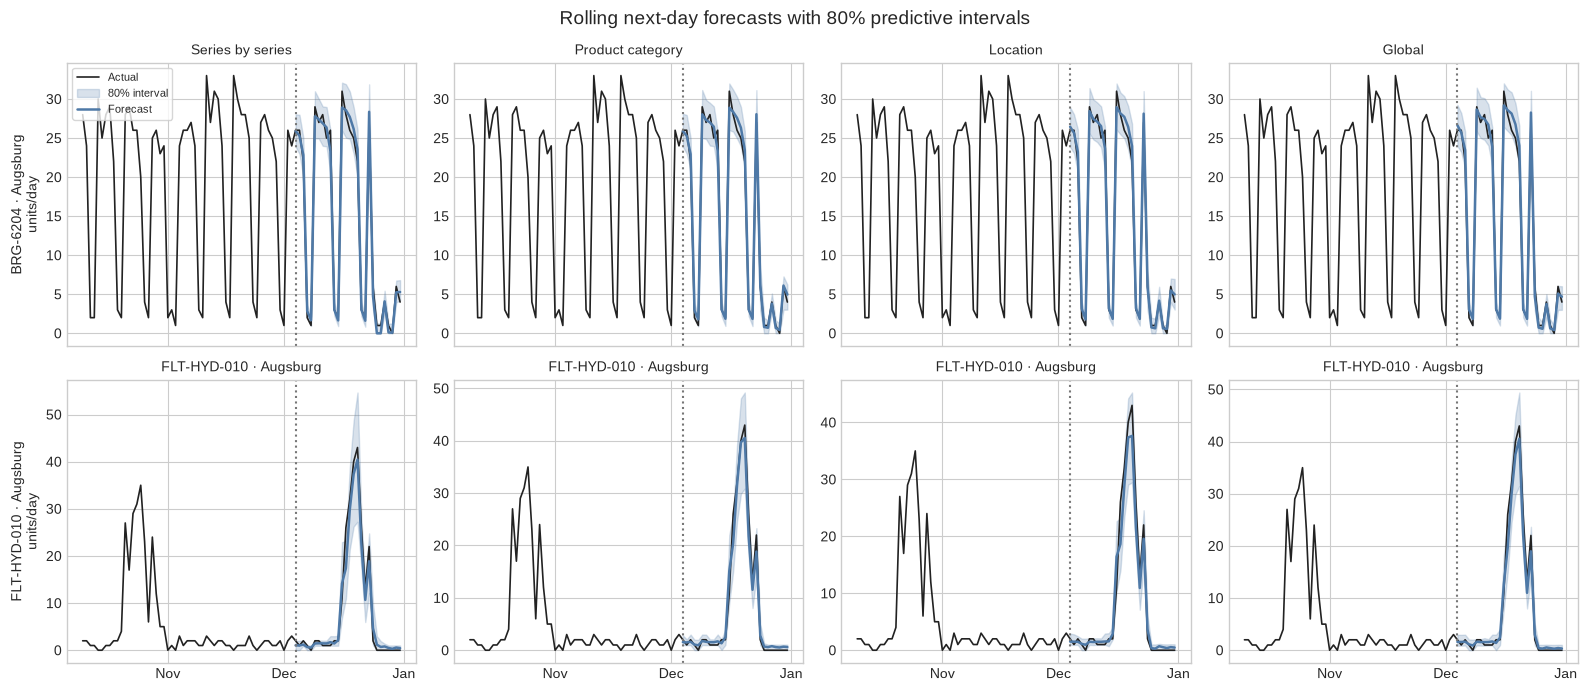

In [9]:
plot_series = ["BRG-6204 · Augsburg", "FLT-HYD-010 · Augsburg"]
strategies = ["Series by series", "Product category", "Location", "Global"]
fig, axes = plt.subplots(len(plot_series), len(strategies), figsize=(16, 7), sharex=True)
for row, series_id in enumerate(plot_series):
    actual = panel[(panel["series_id"] == series_id) & (panel["date"] >= cutoff - pd.Timedelta(days=55))]
    for column, strategy in enumerate(strategies):
        ax = axes[row, column]
        forecast = predictions[(predictions["series_id"] == series_id) & (predictions["strategy"] == strategy)]
        ax.plot(actual["date"], actual["demand"], color="#222222", linewidth=1.2, label="Actual")
        ax.fill_between(forecast["date"], forecast["lower"], forecast["upper"], color="#4E79A7", alpha=0.22, label="80% interval")
        ax.plot(forecast["date"], forecast["prediction"], color="#4E79A7", linewidth=1.8, label="Forecast")
        ax.axvline(cutoff, color="#777777", linestyle=":")
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.set_title(strategy if row == 0 else series_id, fontsize=10)
        if column == 0:
            ax.set_ylabel(f"{series_id}\nunits/day")
axes[0, 0].legend(frameon=True, fontsize=8, loc="upper left")
fig.suptitle("Rolling next-day forecasts with 80% predictive intervals", fontsize=14)
fig.tight_layout()
plt.show()

## Takeaways

Pooling can help when related series share calendar, maintenance, or plant-level patterns; local models remain useful when a series has enough history and distinct dynamics. Choose the level with repeated rolling backtests, not a single split. For fixed multi-day forecasts, replace this next-day setup with direct-horizon or recursive features, and add known signals such as work orders, installed-base counts, lead times, and stock-outs.